In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import geopandas as gpd

import folium
from pathlib import Path

DATA = Path('../data/processed')
plt.rcParams['figure.dpi'] = 110

## GUS BDL Stats

(52, 10)


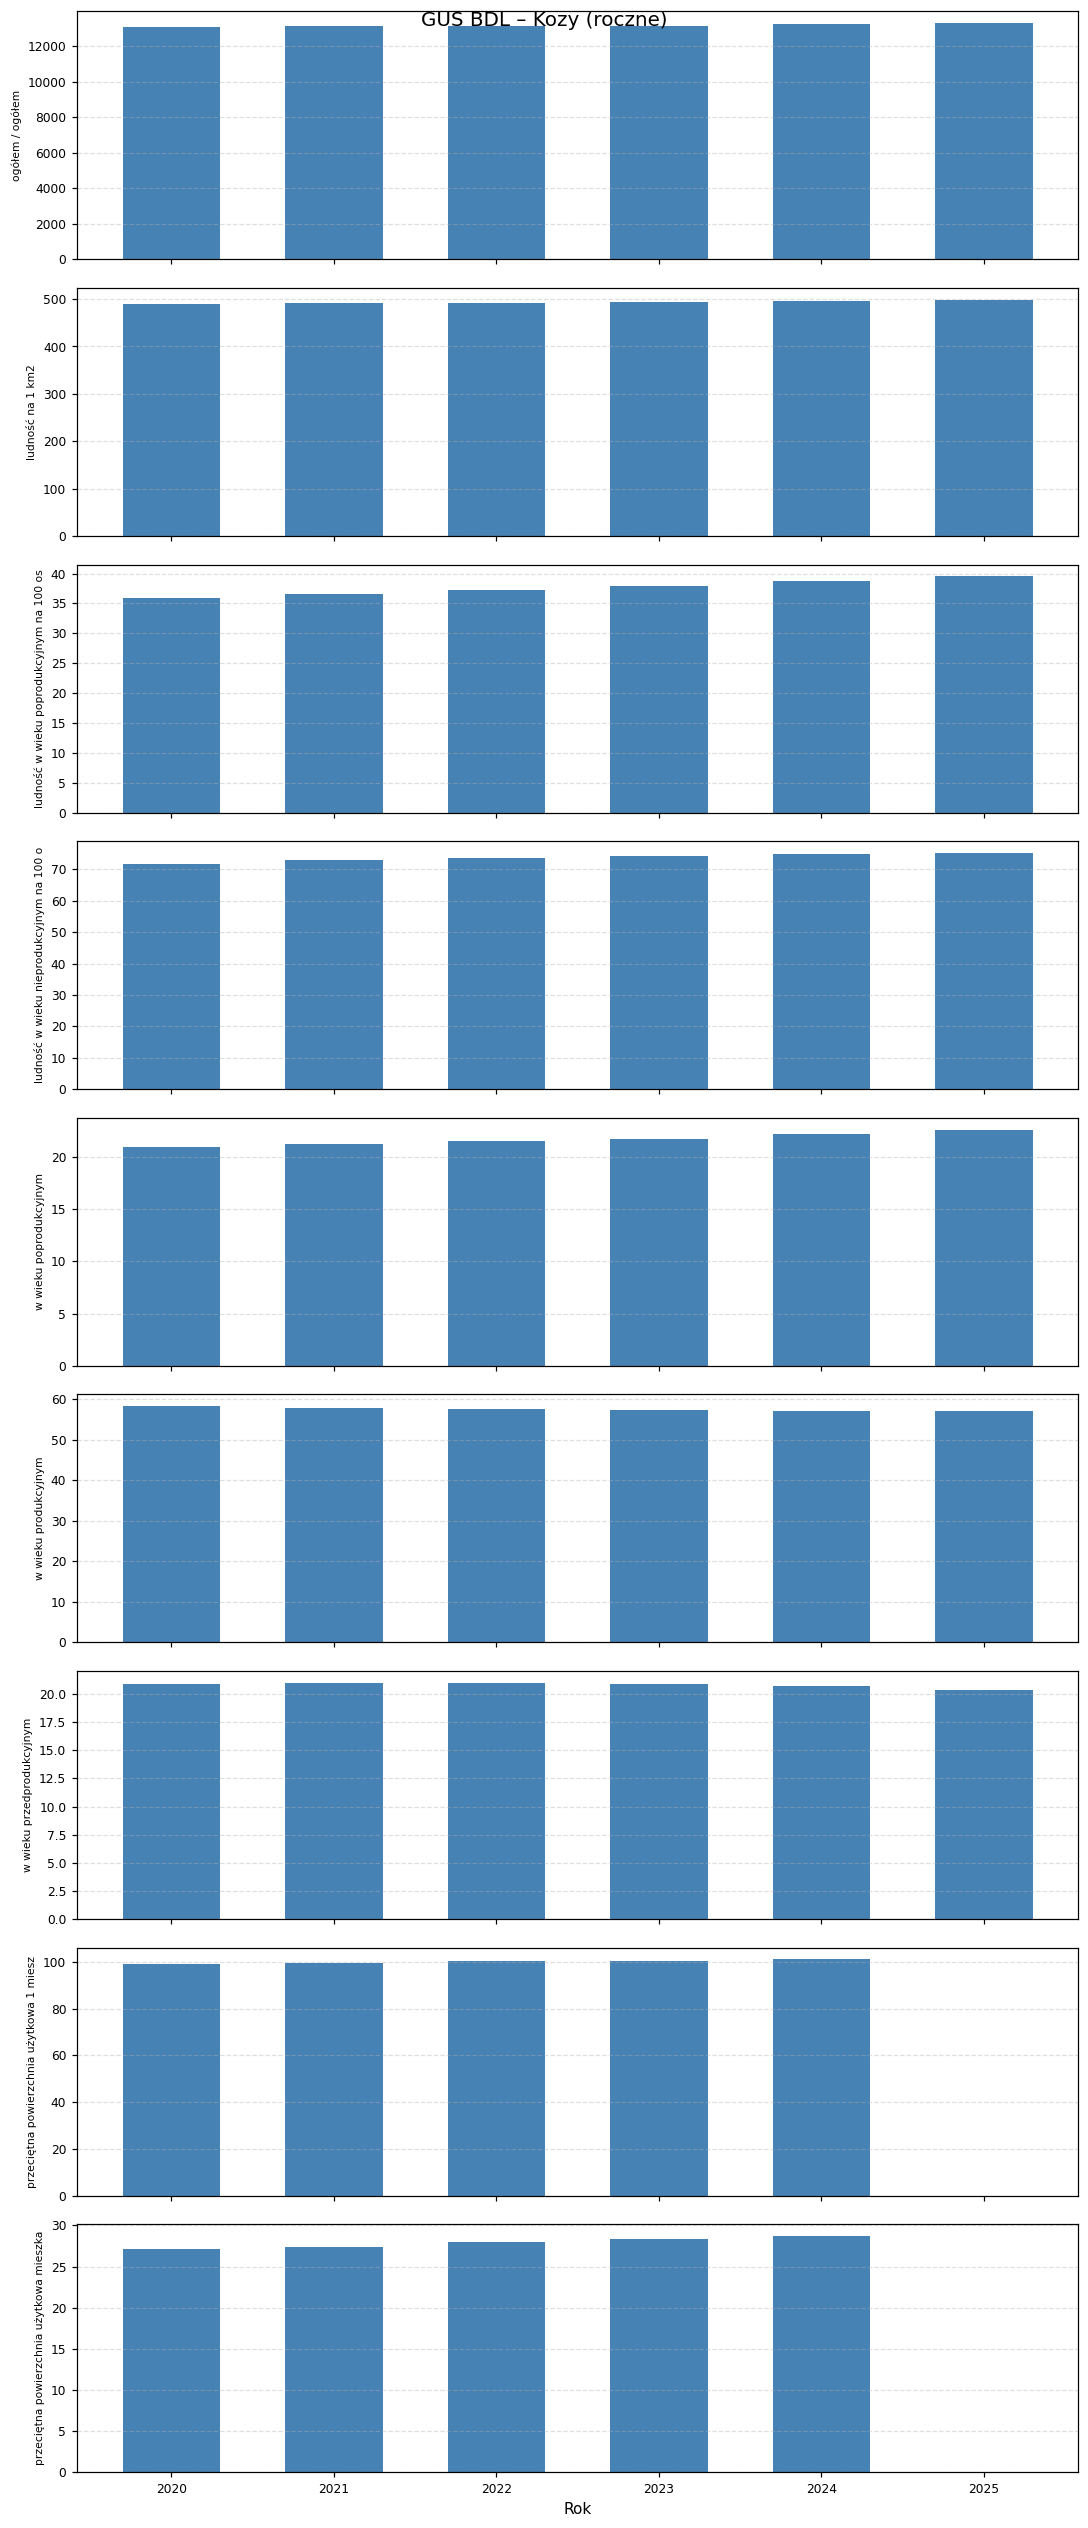

In [3]:
gus = pd.read_parquet(DATA / 'gus_bdl_stats.parquet')
print(gus.shape)

variables = gus['variable_name'].unique()
fig, axes = plt.subplots(len(variables), 1, figsize=(10, 2.6 * len(variables)), sharex=True)
fig.suptitle('GUS BDL – Kozy (roczne)', fontsize=13)

for ax, var in zip(axes, variables):
    sub = gus[gus['variable_name'] == var].sort_values('year')
    ax.bar(sub['year'], sub['value'], color='steelblue', width=0.6)
    ax.set_ylabel(var[:40], fontsize=7)
    ax.tick_params(labelsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

axes[-1].set_xlabel('Rok')
plt.tight_layout()
plt.show()

## IMGW Meteo Daily

(6615, 8) | stacje: <ArrowStringArray>
['PSZCZYNA']
Length: 1, dtype: str


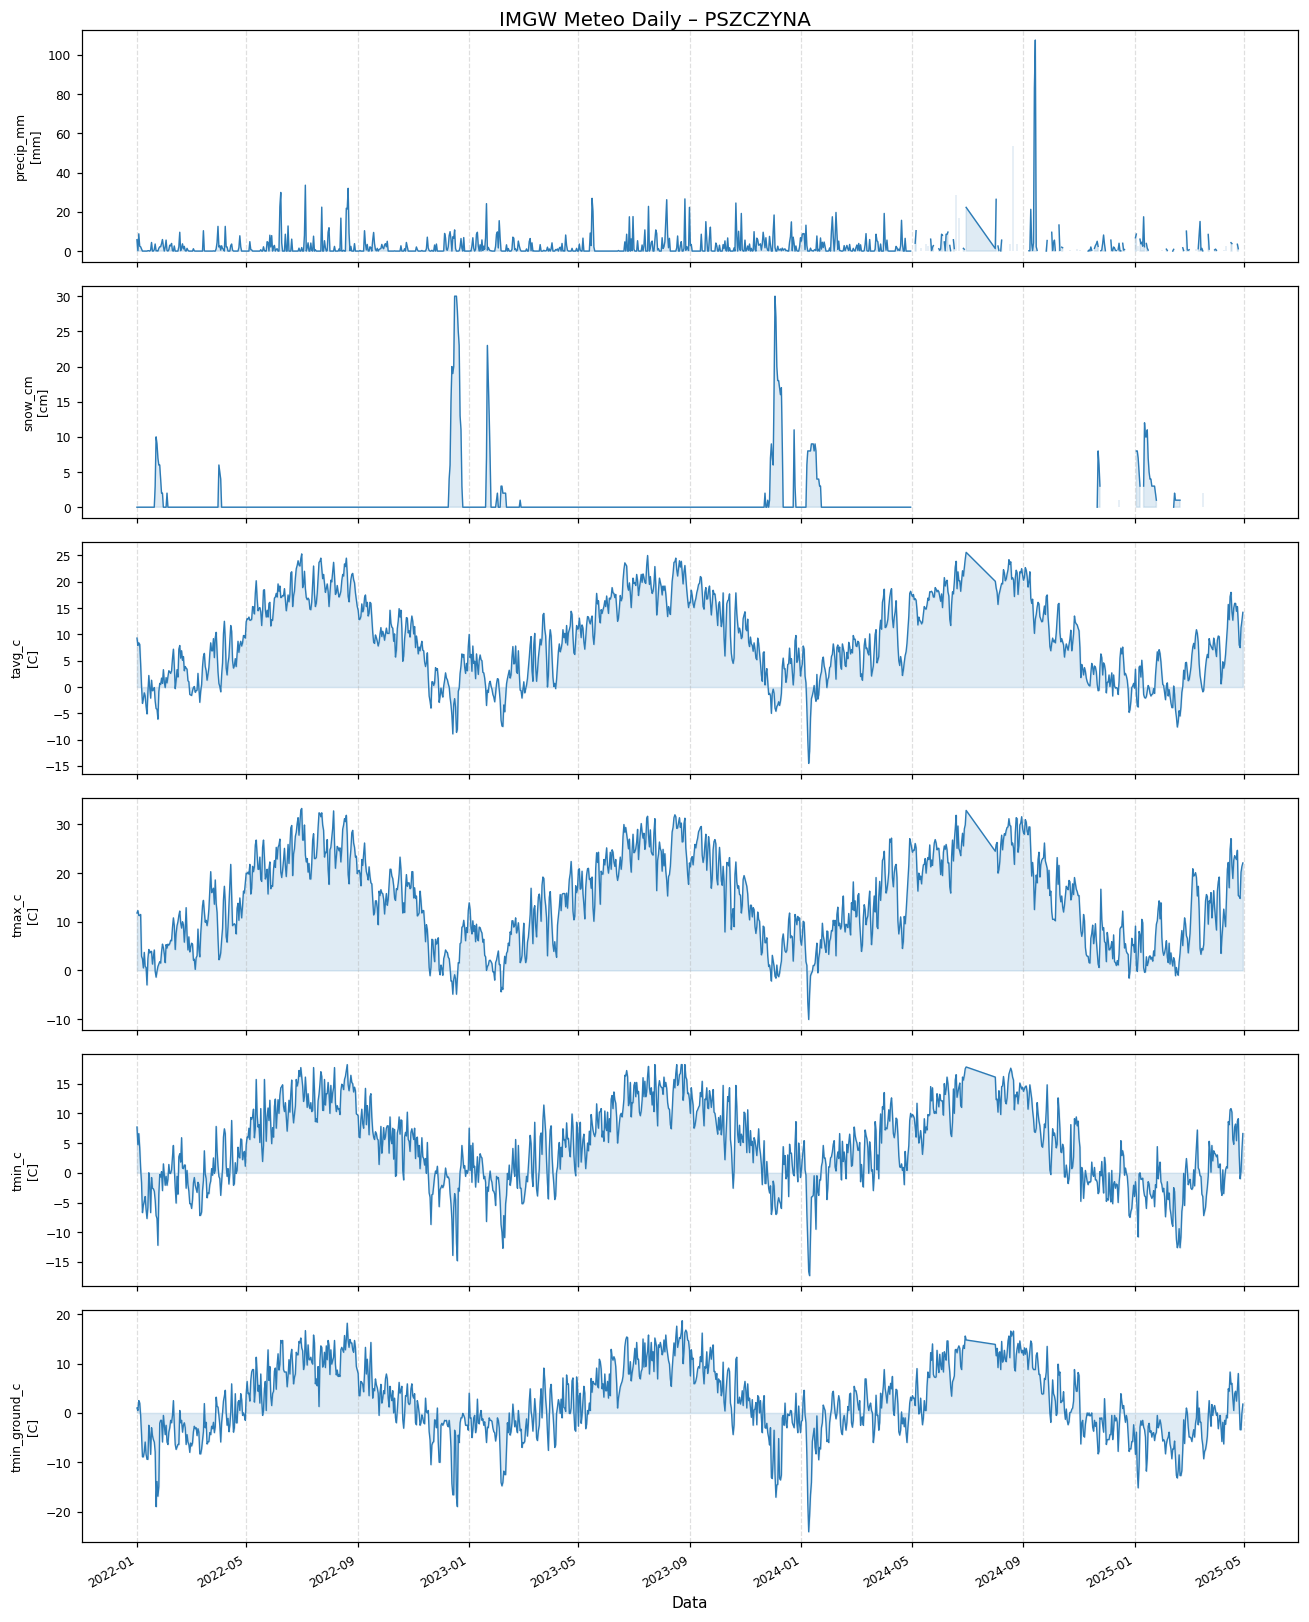

In [4]:
meteo = pd.read_parquet(DATA / 'imgw_meteo_daily.parquet')
print(meteo.shape, '| stacje:', meteo['station'].unique())

pivot = meteo.pivot_table(index='timestamp', columns='variable', values='value', aggfunc='mean')
fig, axes = plt.subplots(len(pivot.columns), 1, figsize=(12, 2.5 * len(pivot.columns)), sharex=True)
fig.suptitle('IMGW Meteo Daily – PSZCZYNA', fontsize=13)

for ax, col in zip(axes, pivot.columns):
    unit = meteo.loc[meteo['variable'] == col, 'unit'].iloc[0]
    ax.plot(pivot.index, pivot[col], linewidth=0.9, color='#2c7bb6')
    ax.fill_between(pivot.index, pivot[col], alpha=0.15, color='#2c7bb6')
    ax.set_ylabel(f'{col}\n[{unit}]', fontsize=8)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel('Data')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## IMGW Hydro Daily

(5792, 8)
                                     count        mean        std     min       25%     50%       75%    max
station              variable                                                                               
CZANIEC-KOBIERNICE   discharge_m3s   724.0   16.977831  20.335008    1.32    2.4875    9.46   21.6000  139.0
                     water_level_cm  724.0  179.400552  31.170123  145.00  157.0000  168.00  190.0000  310.0
CZECHOWICE-DZIEDZICE discharge_m3s   724.0    3.465428   7.999430    0.41    0.9400    1.88    3.4025  169.0
                     water_level_cm  724.0  206.928177  25.561854  181.00  193.0000  202.00  213.0000  564.0
MIKUSZOWICE          discharge_m3s   724.0    0.710925   1.140507    0.11    0.2500    0.44    0.7600   19.7
                     water_level_cm  724.0  120.171271  11.664677   84.00  116.0000  121.00  125.0000  176.0
PODKĘPIE             discharge_m3s   724.0    1.386575   3.309076    0.13    0.3500    0.73    1.4200   65.6
         

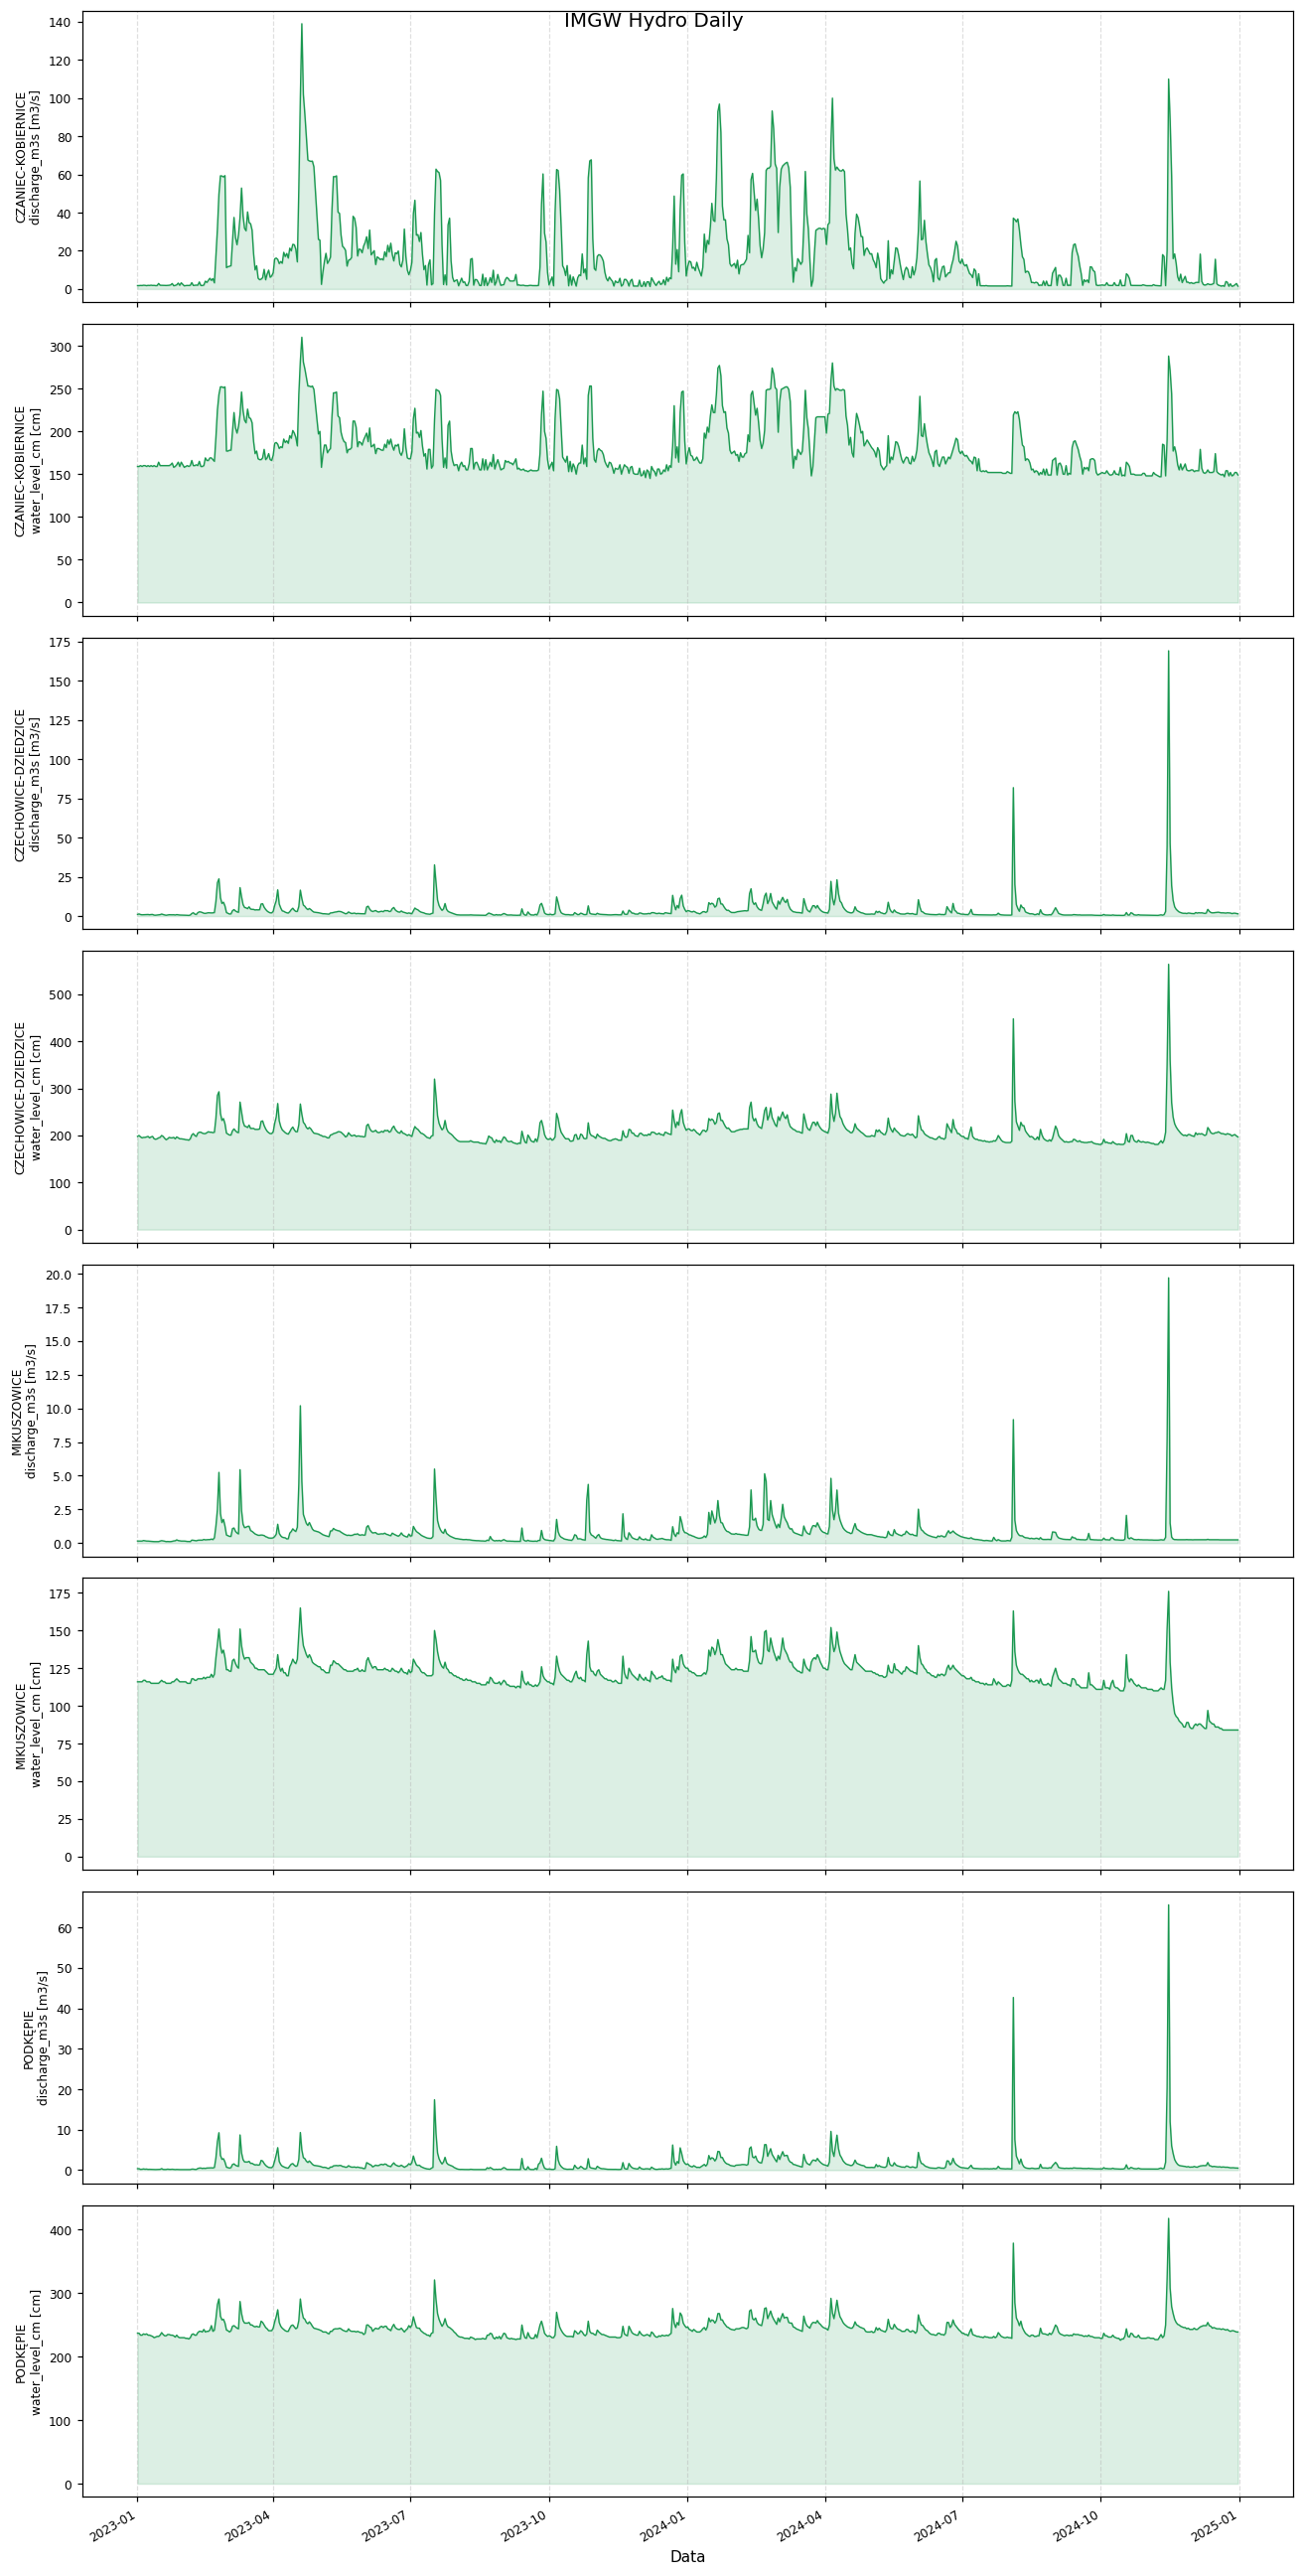

In [5]:
hydro = pd.read_parquet(DATA / 'imgw_hydro_daily.parquet')
print(hydro.shape)
print(hydro.groupby(['station', 'variable'])['value'].describe().to_string())

combos = [(s, v) for s, v in hydro.groupby(['station', 'variable']).groups]
fig, axes = plt.subplots(len(combos), 1, figsize=(12, 3 * len(combos)), sharex=True)
if len(combos) == 1:
    axes = [axes]
fig.suptitle('IMGW Hydro Daily', fontsize=13)

for ax, (station, var) in zip(axes, combos):
    sub = hydro[(hydro['station'] == station) & (hydro['variable'] == var)].sort_values('timestamp')
    unit = sub['unit'].iloc[0]
    ax.plot(sub['timestamp'], sub['value'], linewidth=0.9, color='#1a9850')
    ax.fill_between(sub['timestamp'], sub['value'], alpha=0.15, color='#1a9850')
    ax.set_ylabel(f'{station}\n{var} [{unit}]', fontsize=8)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel('Data')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## GIOS Air Quality

1769 pomiarów | stacje: 3 | zmienne: ['C6H6', 'CO', 'NO', 'NO2', 'NOx', 'O3', 'PM10', 'PM2.5', 'SO2']


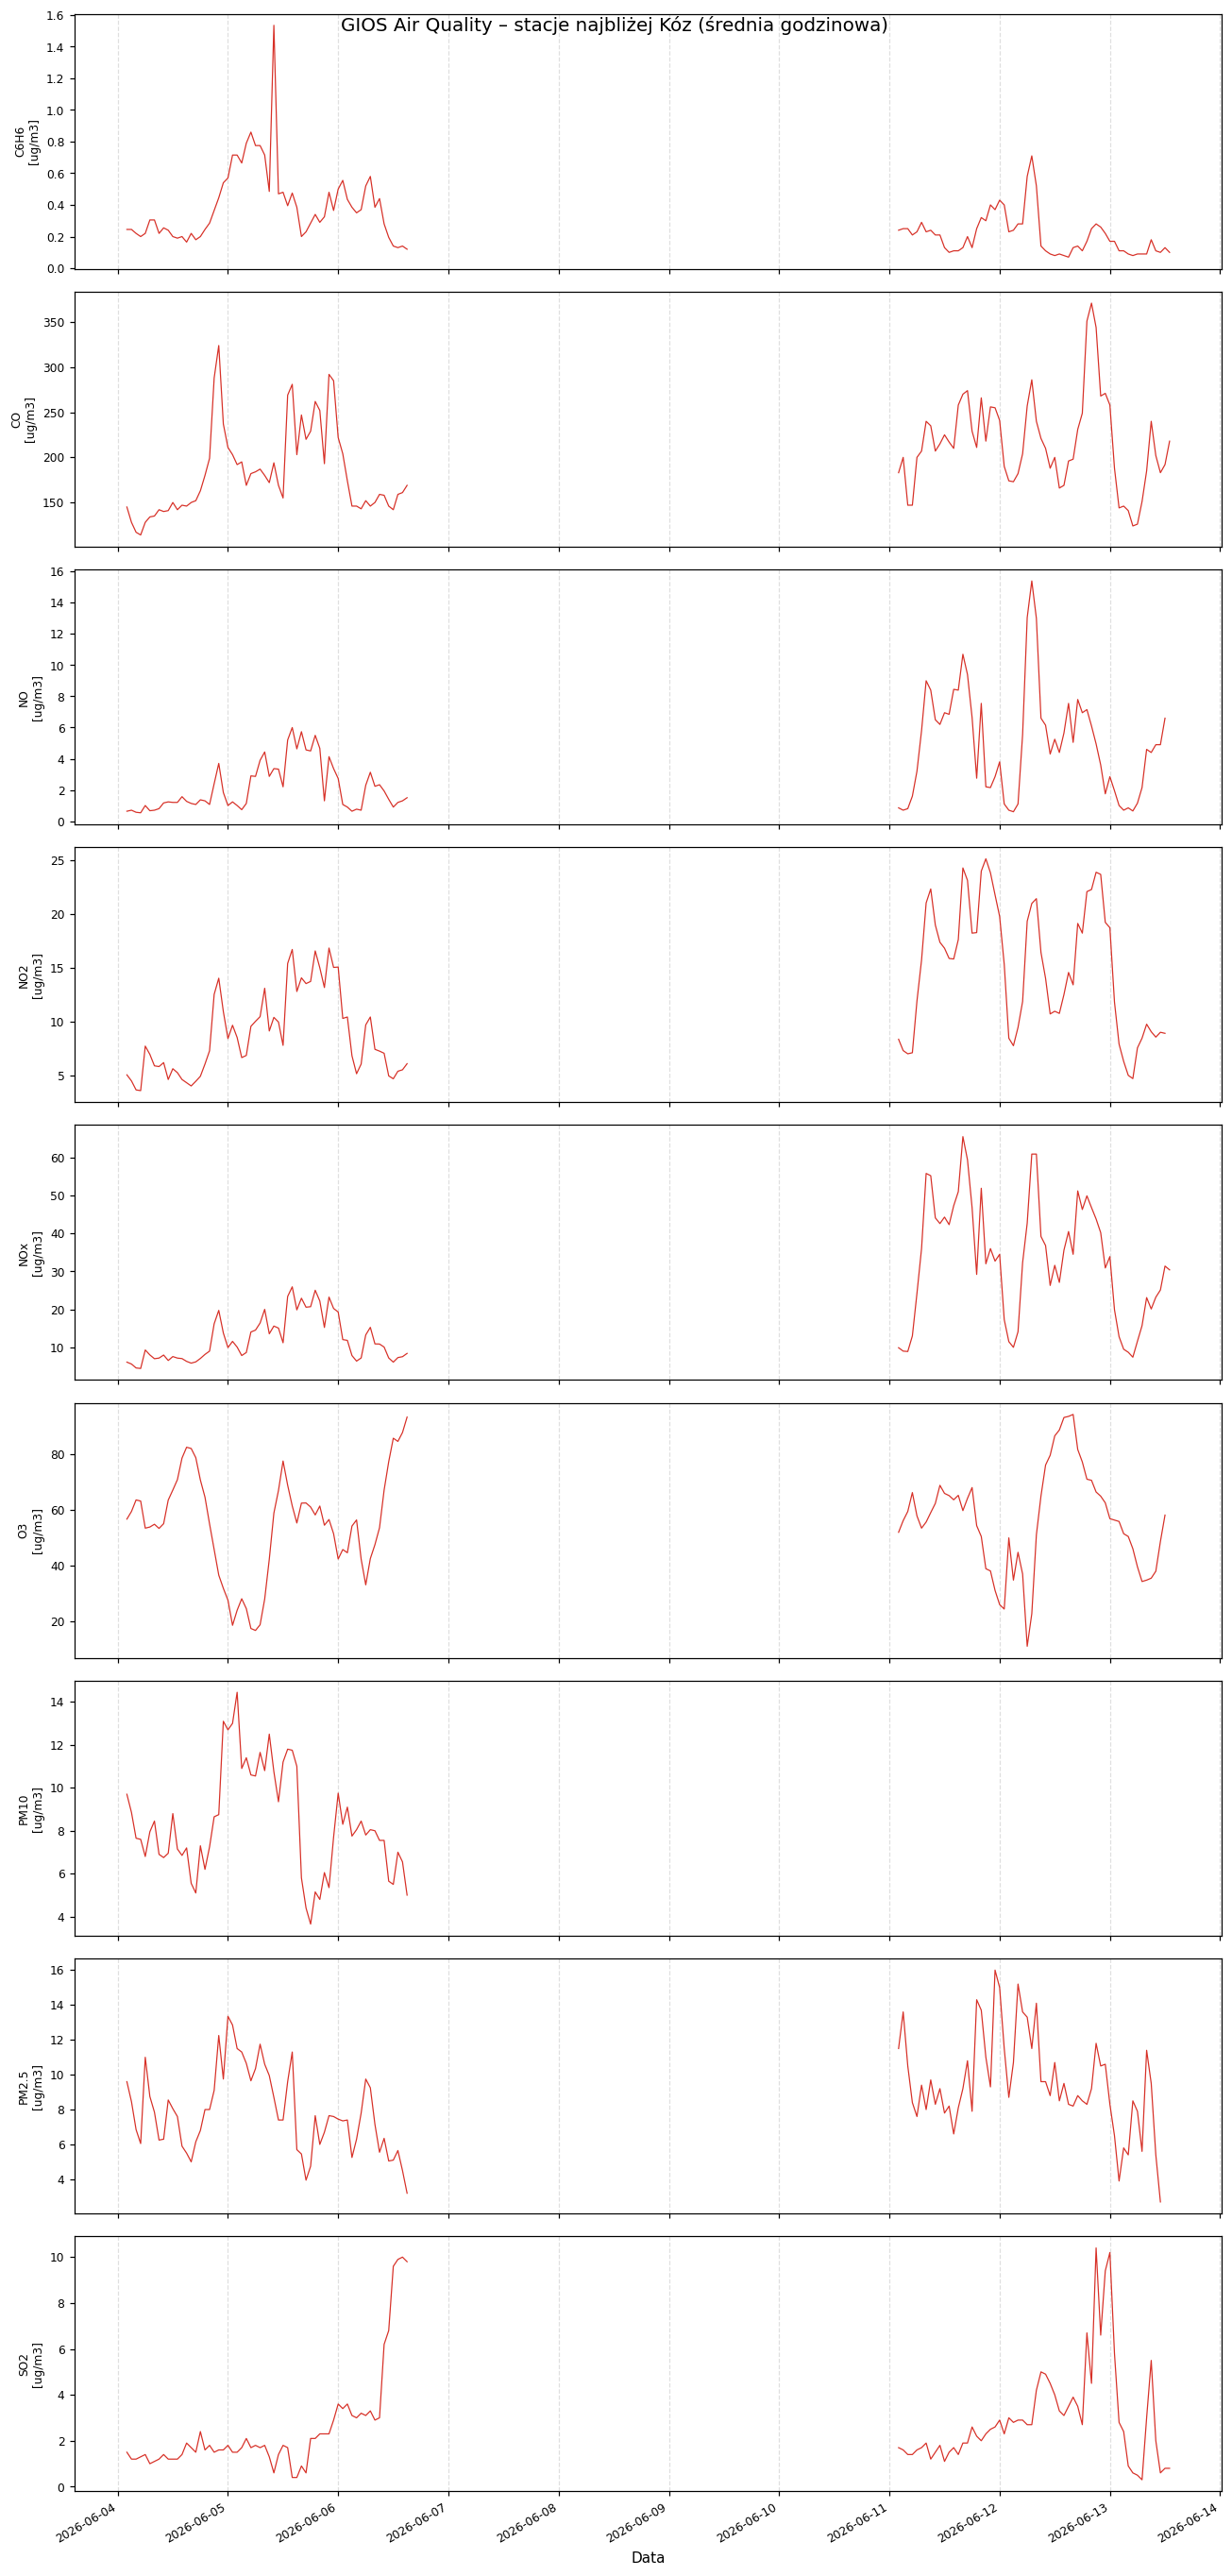

In [6]:
air = pd.read_parquet(DATA / 'gios_air_measurements.parquet')
print(f'{len(air)} pomiarów | stacje: {air["station_id"].nunique()} | zmienne: {sorted(air["variable"].unique())}')

pivot = (
    air.pivot_table(index='timestamp', columns='variable', values='value', aggfunc='mean')
    .resample('h').mean()
)
cols = pivot.columns.tolist()
fig, axes = plt.subplots(len(cols), 1, figsize=(12, 2.8 * len(cols)), sharex=True)
if len(cols) == 1:
    axes = [axes]
fig.suptitle('GIOS Air Quality – stacje najbliżej Kóz (średnia godzinowa)', fontsize=13)

for ax, col in zip(axes, cols):
    unit = air.loc[air['variable'] == col, 'unit'].iloc[0]
    ax.plot(pivot.index, pivot[col], linewidth=0.8, color='#d73027')
    ax.set_ylabel(f'{col}\n[{unit}]', fontsize=8)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel('Data')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Open Meteo Weather

33,840,000 wierszy | zmienne: ['cloud_cover', 'precipitation', 'rain', 'relative_humidity_2m', 'snowfall', 'soil_moisture_0_to_7cm', 'soil_temperature_0_to_7cm', 'surface_pressure', 'temperature_2m', 'wind_direction_10m', 'wind_gusts_10m', 'wind_speed_10m']


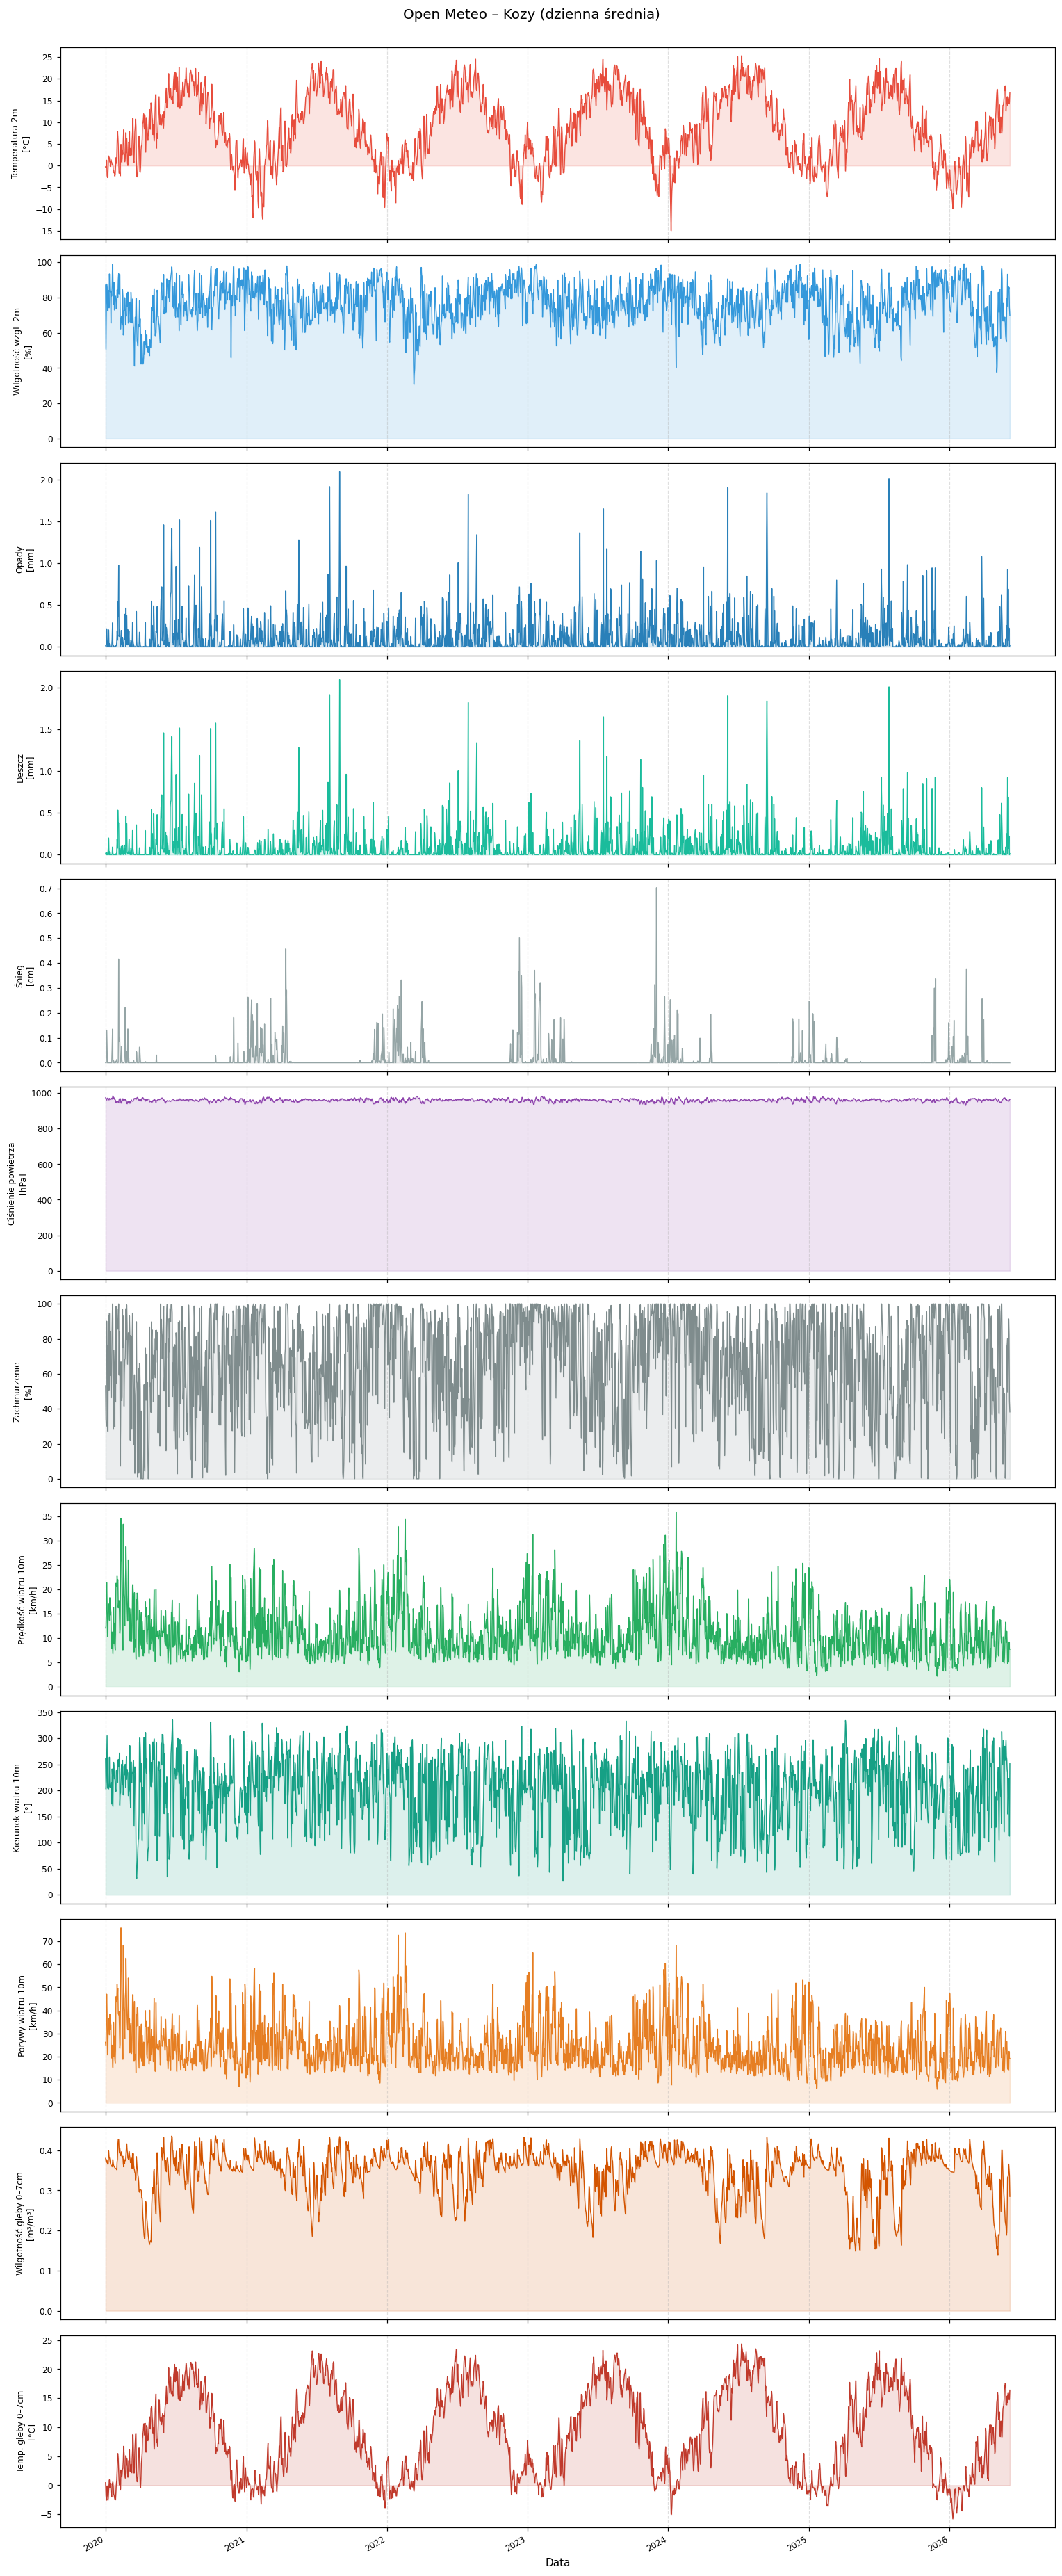

In [7]:
weather = pd.read_parquet(DATA / 'open_meteo_weather.parquet')
print(f'{len(weather):,} wierszy | zmienne: {sorted(weather["variable"].unique())}')

pivot = (
    weather.groupby(['timestamp', 'variable'])['value']
    .mean().unstack('variable')
    .resample('D').mean()
)

VAR_META = {
    'temperature_2m':            ('Temperatura 2m',       '°C',    '#e74c3c'),
    'relative_humidity_2m':      ('Wilgotność wzgl. 2m',  '%',     '#3498db'),
    'precipitation':             ('Opady',                'mm',    '#2980b9'),
    'rain':                      ('Deszcz',               'mm',    '#1abc9c'),
    'snowfall':                  ('Śnieg',                'cm',    '#95a5a6'),
    'surface_pressure':          ('Ciśnienie powietrza',  'hPa',   '#8e44ad'),
    'cloud_cover':               ('Zachmurzenie',         '%',     '#7f8c8d'),
    'wind_speed_10m':            ('Prędkość wiatru 10m',  'km/h',  '#27ae60'),
    'wind_direction_10m':        ('Kierunek wiatru 10m',  '°',     '#16a085'),
    'wind_gusts_10m':            ('Porywy wiatru 10m',    'km/h',  '#e67e22'),
    'soil_moisture_0_to_7cm':    ('Wilgotność gleby 0–7cm', 'm³/m³', '#d35400'),
    'soil_temperature_0_to_7cm': ('Temp. gleby 0–7cm',   '°C',    '#c0392b'),
}

cols = [c for c in VAR_META if c in pivot.columns]
fig, axes = plt.subplots(len(cols), 1, figsize=(14, 2.8 * len(cols)), sharex=True)
fig.suptitle('Open Meteo – Kozy (dzienna średnia)', fontsize=13, y=1.001)

for ax, col in zip(axes, cols):
    label, unit, color = VAR_META[col]
    ax.plot(pivot.index, pivot[col], color=color, linewidth=0.9)
    ax.fill_between(pivot.index, pivot[col], alpha=0.15, color=color)
    ax.set_ylabel(f'{label}\n[{unit}]', fontsize=8)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel('Data')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## OSM Features

8274 elementów | kategorie: ['amenity', 'building', 'highway', 'landuse', 'natural', 'shop', 'waterway']


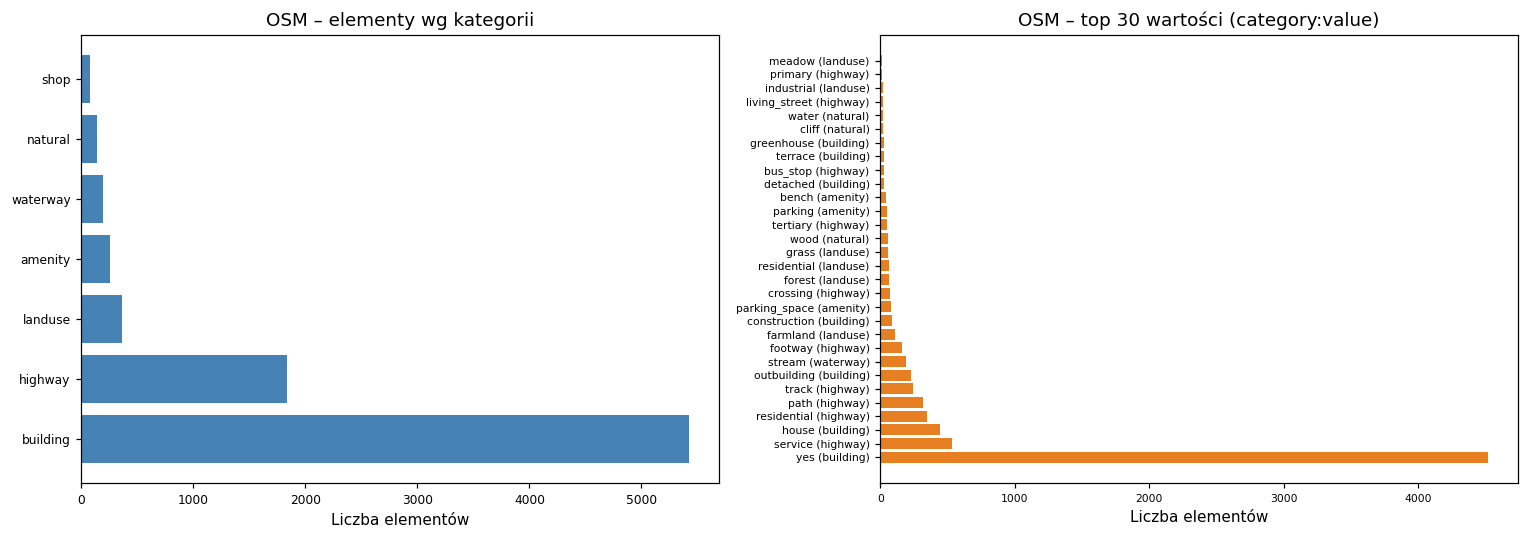

In [8]:
osm = pd.read_parquet(DATA / 'osm_features.parquet')
print(f'{len(osm)} elementów | kategorie: {sorted(osm["category"].unique())}')

cat_counts = osm.groupby(['category', 'value']).size().reset_index(name='n')
top_values = cat_counts.sort_values('n', ascending=False).head(30)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# lewy: liczba elementów wg kategorii
cat_total = osm['category'].value_counts()
axes[0].barh(cat_total.index, cat_total.values, color='steelblue')
axes[0].set_xlabel('Liczba elementów')
axes[0].set_title('OSM – elementy wg kategorii')
axes[0].tick_params(labelsize=8)

# prawy: top 30 wartości
axes[1].barh(top_values['value'] + ' (' + top_values['category'] + ')',
             top_values['n'], color='#e67e22')
axes[1].set_xlabel('Liczba elementów')
axes[1].set_title('OSM – top 30 wartości (category:value)')
axes[1].tick_params(labelsize=7)

plt.tight_layout()
plt.show()

In [23]:
boundary = gpd.read_file(DATA / 'kozy_boundary.geojson')
df_map = osm[osm['category'] != 'highway'].dropna(subset=['name'])
print(df_map.category.value_counts())

df_map = df_map[df_map['category'].isin(['natural','building','amenity'])]
print(len(df_map))
print(df_map[['osm_type','category','name']].sample(10))
COLORS = {
    'amenity': 'red', 'shop': 'blue', 'natural': 'green',
    'tourism': 'purple', 'leisure': 'orange', 'sport': 'cadetblue',
    'landuse': 'darkgreen', 'building': 'gray', 'place': 'darkred',
}

m = folium.Map(
    location=[df_map['lat'].mean(), df_map['lon'].mean()],
    zoom_start=13,
    tiles='CartoDB positron'
)

# granica Kóz
folium.GeoJson(
    boundary.__geo_interface__,
    style_function=lambda _: {'color': '#2c3e50', 'weight': 2, 'fillOpacity': 0.05}
).add_to(m)

for _, row in df_map.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=4,
        color=COLORS.get(row['category'], 'gray'),
        fill=True, fill_opacity=0.8,
        popup=f"<b>{row.get('name', '')}</b><br>{row['category']}: {row['value']}",
        tooltip=row.get('name', ''),
    ).add_to(m)

m.save('osm_map.html')
# m

category
shop        55
waterway    55
amenity     50
building    22
natural     14
landuse      3
Name: count, dtype: int64
86
     osm_type  category                                               name
2183      way  building                                            Klimors
8126      way  building                                            Exponet
376       way   amenity                                        Dom Kultury
7        node   natural                                          Przegibek
5        node   natural                                     Żródło Maryjne
397       way   natural                                        Wilczy staw
2717      way   amenity                                        AMIC Energy
2839      way   amenity  Szkoła Podstawowa nr 1 z Oddziałami Integracyj...
142      node   amenity                        Gminna Biblioteka Publiczna
5429      way  building                              Biblioteka parafialna


## Kozy Boundary + Spatial Grid

50 punktów | wysokość 331–811 m n.p.m.


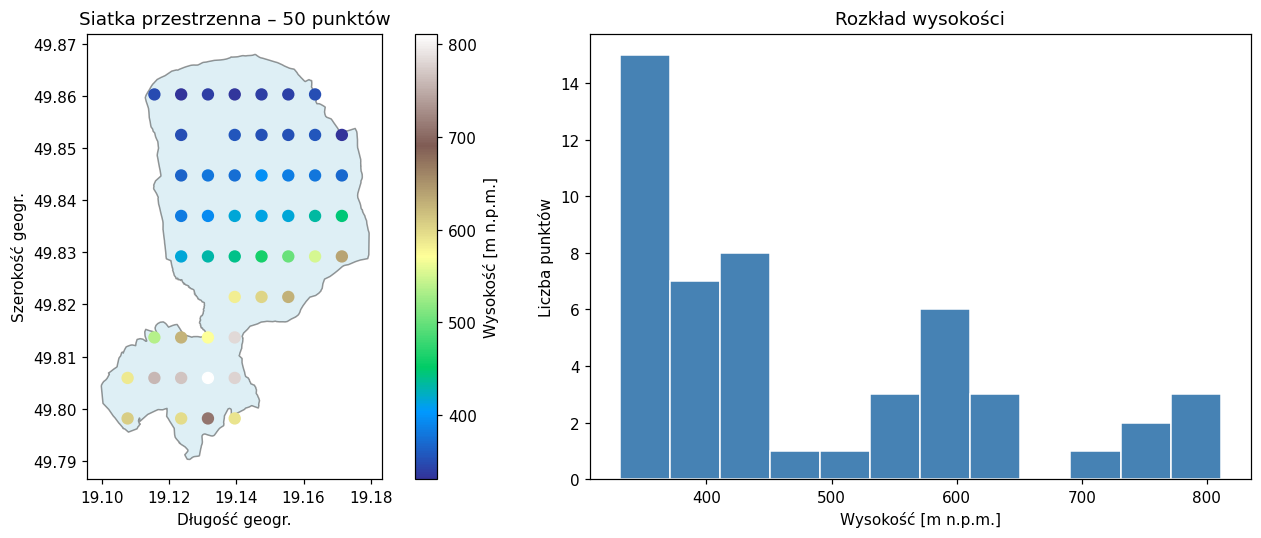

In [10]:
boundary = gpd.read_file(DATA / 'kozy_boundary.geojson')
grid = pd.read_parquet(DATA / 'spatial_grid.parquet')
print(f'{len(grid)} punktów | wysokość {grid["elevation_m"].min():.0f}–{grid["elevation_m"].max():.0f} m n.p.m.')

fig, (ax_map, ax_hist) = plt.subplots(1, 2, figsize=(13, 5))

boundary.plot(ax=ax_map, edgecolor='black', facecolor='lightblue', alpha=0.4)
sc = ax_map.scatter(grid['lon'], grid['lat'], c=grid['elevation_m'],
                    cmap='terrain', s=50, zorder=3)
plt.colorbar(sc, ax=ax_map, label='Wysokość [m n.p.m.]')
ax_map.set_title(f'Siatka przestrzenna – {len(grid)} punktów')
ax_map.set_xlabel('Długość geogr.'); ax_map.set_ylabel('Szerokość geogr.')

ax_hist.hist(grid['elevation_m'].dropna(), bins=12, color='steelblue', edgecolor='white')
ax_hist.set_xlabel('Wysokość [m n.p.m.]'); ax_hist.set_ylabel('Liczba punktów')
ax_hist.set_title('Rozkład wysokości')

plt.tight_layout()
plt.show()

## Zdarzenia: Kozy News / RCB Alerts / Meteoalarm / Tauron Outages

In [ ]:
news = pd.read_parquet(DATA / 'kozy_news.parquet')
rcb = pd.read_parquet(DATA / 'rcb_alerts.parquet')
ma = pd.read_parquet(DATA / 'meteoalarm_warnings.parquet')
tauron = pd.read_parquet(DATA / 'tauron_outages.parquet')

for name, df in [('Kozy News', news), ('RCB Alerts', rcb), ('Meteoalarm', ma), ('Tauron Outages', tauron)]:
    print(f'{name}: {len(df)} wierszy  ({df["timestamp"].min().date()} – {df["timestamp"].max().date()})')

Kozy News: 14 wierszy  (2026-05-15 – 2026-06-11)
RCB Alerts: 2 wierszy  (2026-06-03 – 2026-06-09)
Meteoalarm: 7 wierszy  (2026-06-02 – 2026-06-13)
Tauron Outages: 15 wierszy  (2026-03-11 – 2026-06-12)


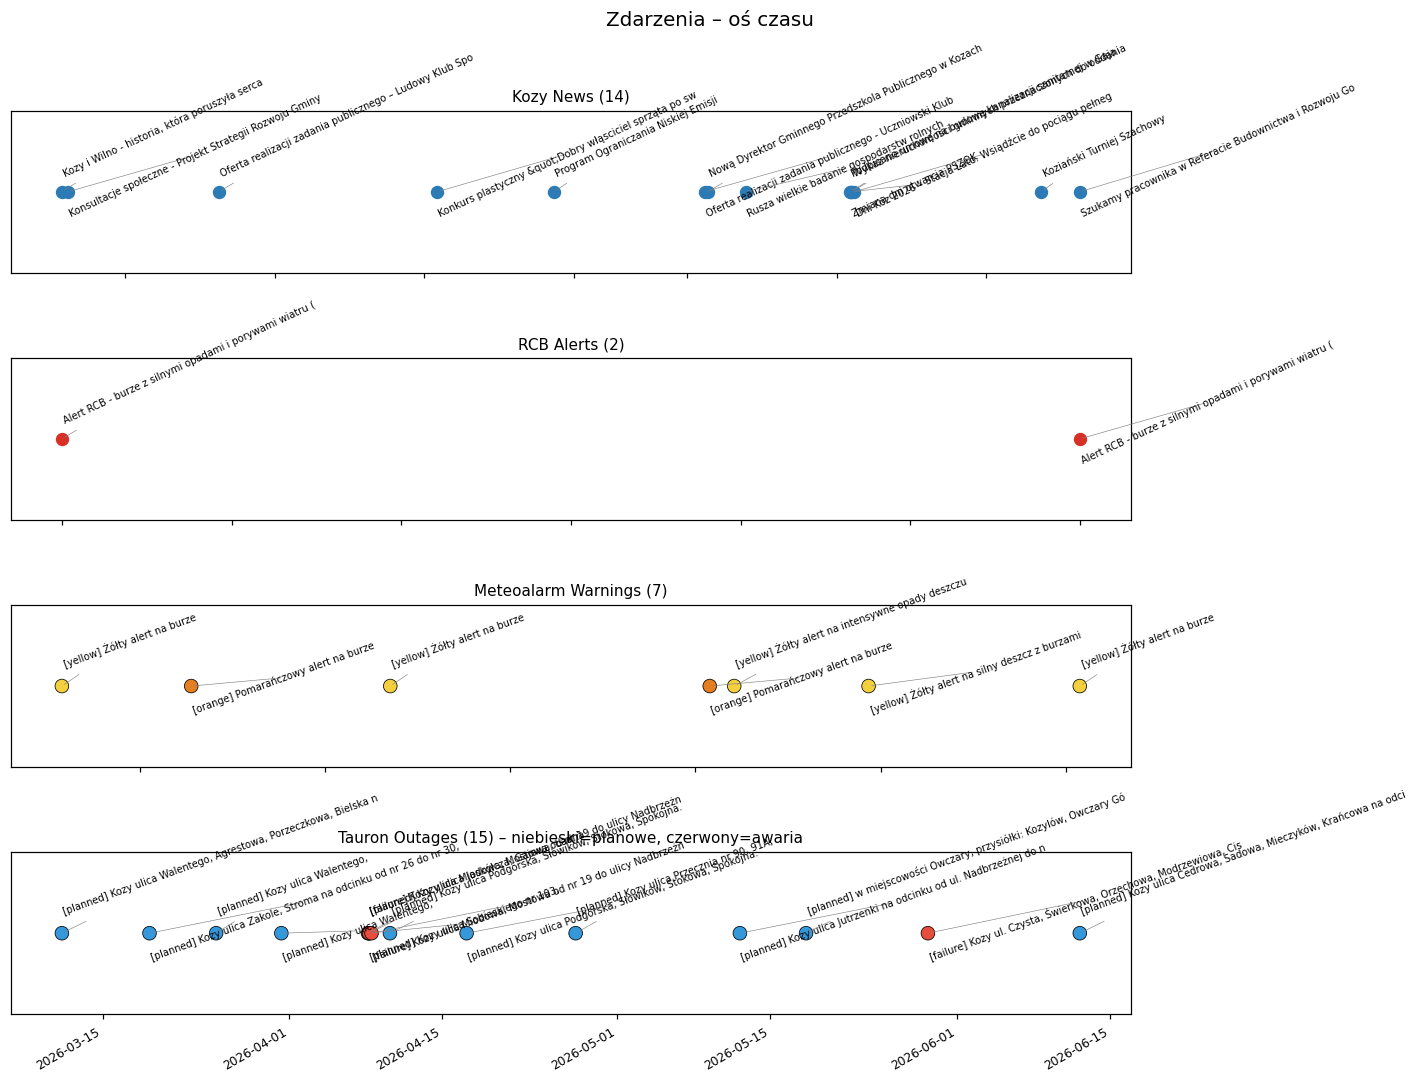

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=False)
fig.suptitle('Zdarzenia – oś czasu', fontsize=13)

def plot_events(ax, df, title, color, label_col='title', y_offset=0):
    ts = pd.to_datetime(df['timestamp']).sort_values()
    ax.scatter(ts, [y_offset] * len(ts), s=60, color=color, zorder=3)
    for i, (t, lbl) in enumerate(zip(ts, df.loc[ts.index, label_col])):
        ax.annotate(
            str(lbl)[:55],
            xy=(t, y_offset),
            xytext=(0, 10 if i % 2 == 0 else -16),
            textcoords='offset points',
            fontsize=6.5, rotation=25, ha='left',
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.4)
        )
    ax.set_yticks([])
    ax.set_title(title, fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    ax.tick_params(axis='x', labelsize=8)
    fig.autofmt_xdate()

plot_events(axes[0], news,   f'Kozy News ({len(news)})',          '#2c7bb6')
plot_events(axes[1], rcb,    f'RCB Alerts ({len(rcb)})',           '#d73027')

# Meteoalarm – kolory wg poziomu alertu
level_color = {'yellow': '#f4d03f', 'orange': '#e67e22', 'red': '#c0392b'}
ts_ma = pd.to_datetime(ma['timestamp']).sort_values()
colors_ma = [level_color.get(ma.loc[i, 'category'], 'gray') for i in ts_ma.index]
axes[2].scatter(ts_ma, [0] * len(ts_ma), s=80, c=colors_ma, zorder=3, edgecolors='black', linewidths=0.5)
for i, (t, lbl, cat) in enumerate(zip(ts_ma, ma.loc[ts_ma.index, 'title'], ma.loc[ts_ma.index, 'category'])):
    axes[2].annotate(
        f'[{cat}] {str(lbl)[:50]}',
        xy=(t, 0), xytext=(0, 12 if i % 2 == 0 else -18),
        textcoords='offset points', fontsize=6.5, rotation=20, ha='left',
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.4)
    )
axes[2].set_yticks([])
axes[2].set_title(f'Meteoalarm Warnings ({len(ma)})', fontsize=10)
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[2].tick_params(axis='x', labelsize=8)

# Tauron – planned vs failure
cat_color = {'planned': '#3498db', 'failure': '#e74c3c'}
ts_t = pd.to_datetime(tauron['timestamp']).sort_values()
colors_t = [cat_color.get(tauron.loc[i, 'category'], 'gray') for i in ts_t.index]
axes[3].scatter(ts_t, [0] * len(ts_t), s=80, c=colors_t, zorder=3, edgecolors='black', linewidths=0.5)
for i, (t, lbl, cat) in enumerate(zip(ts_t, tauron.loc[ts_t.index, 'title'], tauron.loc[ts_t.index, 'category'])):
    axes[3].annotate(
        f'[{cat}] {str(lbl)[:55]}',
        xy=(t, 0), xytext=(0, 12 if i % 2 == 0 else -18),
        textcoords='offset points', fontsize=6.5, rotation=20, ha='left',
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.4)
    )
axes[3].set_yticks([])
axes[3].set_title(f'Tauron Outages ({len(tauron)}) – niebieski=planowe, czerwony=awaria', fontsize=10)
axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[3].tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()

/tmp/ipykernel_62355/808628584.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  tauron_m['month'] = pd.to_datetime(tauron_m['timestamp']).dt.to_period('M')


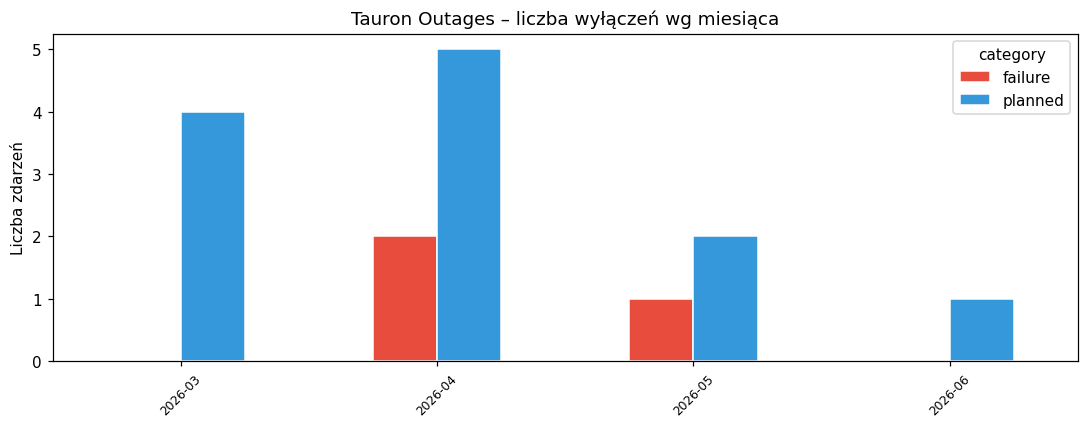

In [13]:
# Tauron – bar chart wg miesiąca
tauron_m = tauron.copy()
tauron_m['month'] = pd.to_datetime(tauron_m['timestamp']).dt.to_period('M')
pivot_t = tauron_m.groupby(['month', 'category']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
pivot_t.plot(kind='bar', ax=ax,
             color=[cat_color.get(c, 'gray') for c in pivot_t.columns],
             edgecolor='white')
ax.set_title('Tauron Outages – liczba wyłączeń wg miesiąca')
ax.set_xlabel('')
ax.set_ylabel('Liczba zdarzeń')
ax.tick_params(axis='x', labelsize=8, rotation=45)
plt.tight_layout()
plt.show()

## Meteoalarm – szczegóły

In [14]:
print(f'{len(ma)} ostrzeżeń (akumulowane przy kolejnych uruchomieniach)\n')
for _, row in ma.sort_values('timestamp', ascending=False).iterrows():
    dur = (row['expires'] - row['timestamp']).total_seconds() / 3600
    print(f"[{row['category'].upper()}] {row['title']}")
    print(f"  {row['timestamp'].strftime('%Y-%m-%d %H:%M')} → {row['expires'].strftime('%H:%M')} ({dur:.1f} h)")
    print(f"  {row['description'][:120]}...\n")

7 ostrzeżeń (akumulowane przy kolejnych uruchomieniach)

[YELLOW] Żółty alert na burze
  2026-06-13 03:38 → 21:00 (17.4 h)
  Miejscami wystąpią burze, którym będą towarzyszyć silne opady deszczu do 30 mm. Porywy wiatru do 60 km/h, lokalnie opady...

[YELLOW] Żółty alert na silny deszcz z burzami
  2026-06-10 20:53 → 11:00 (14.1 h)
  Prognozowane są opady deszczu o natężeniu umiarkowanym, okresami silnym. Wysokość opadu miejscami od 20 mm do 30 mm, lok...

[YELLOW] Żółty alert na intensywne opady deszczu
  2026-06-09 10:03 → 12:00 (25.9 h)
  Prognozowane są opady deszczu okresami o natężeniu umiarkowanym i silnym. Prognozowana wysokość opadów miejscami od 25 m...

[ORANGE] Pomarańczowy alert na burze
  2026-06-09 03:43 → 21:00 (17.3 h)
  Wystąpią burze, którym będą towarzyszyć silne i bardzo silne opady deszczu od 20 mm do 35 mm, miejscami około 45 mm. Lok...

[YELLOW] Żółty alert na burze
  2026-06-05 16:54 → 21:00 (4.1 h)
  Prognozowane są burze, którym miejscami będą towarzyszyć  opa